# Phase 4 — Train model_25m on Kaggle TPU v5e-8

**Before you start:**
1. Mount the `llm-forge-tokens-v1` dataset from the Kaggle sidebar (+ Add data → search `adeshboudh/llm-forge-tokens-v1`).
2. Run the cells in order. Cells 1-3 install the repo + jax/jaxlib/libtpu; cells 4-6 verify the env; cell 7+ run training.

**Why a separate jax/jaxlib/libtpu install?** `uv sync` in cell 2 installs jax from pypi per pyproject's `jax>=0.4.20` pin, which on Kaggle's Python 3.14 returns the CPU jaxlib. Cell 3 forces a reinstall of jax/jaxlib/libtpu from pypi into the venv. The pypi jaxlib 0.10.2 is TPU-capable (jaxlib is built for all backends), and the libtpu pip package finds the pre-installed libtpu.so on the Kaggle TPU VM. After cell 3, `jax.devices()` returns 8 TPU devices.

In [14]:
!git clone https://github.com/adeshboudh/llm_forge.git 2>/dev/null || (cd llm_forge && git pull)

Already up to date.


In [15]:
!pwd

/kaggle/working/llm_forge


In [16]:
!git pull

remote: Enumerating objects: 17, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 9 (delta 7), reused 9 (delta 7), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 2.35 KiB | 1.18 MiB/s, done.
From https://github.com/adeshboudh/llm_forge
   7057aae..e189293  main       -> origin/main
Updating 7057aae..e189293
Fast-forward
 notebooks/phase4-training/train_25m.ipynb |  8 ++++-
 training/export_hf.py                     | 23 ++++++++++--
 training/tests/test_export_hf.py          | 59 +++++++++++++++++++++++++++++--
 3 files changed, 85 insertions(+), 5 deletions(-)


In [2]:
!pip install uv && cd llm_forge && uv sync --extra dev

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.3/26.3 MB 41.7 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Using CPython 3.14.6
Creating virtual environment at: .venv
Resolved 77 packages in 1.04s                                        
Prepared 71 packages in 2.87s                                            
░░░░░░░░░░░░░░░░░░░░ [0/71] Installing wheels...                                warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 71 packages in 522ms                              
 + absl-py==2.4.0
 + aiofiles==25.1.0
 + aiohappyeyeballs==2.6.2
 + aiohttp==3.14.1
 + aiosignal==1.4.0
 + annotated-doc==0.0.4

In [3]:
# Reinstall jax/jaxlib/libtpu into the venv from pypi (NOT the libtpu_releases
# index, which only has pre-release nightly libtpu wheels). jax 0.10.2 + jaxlib
# 0.10.2 from pypi has cp314 wheels and is TPU-capable; the libtpu pip package
# finds the pre-installed libtpu.so on the Kaggle TPU VM (no compile needed).
# --reinstall overrides whatever uv sync installed in cell 2.
!cd llm_forge && uv pip install --reinstall jax jaxlib libtpu

Resolved 7 packages in 147ms                                         
Prepared 7 packages in 2.02s                                             
Uninstalled 6 packages in 175ms
░░░░░░░░░░░░░░░░░░░░ [0/7] Installing wheels...                                 warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 7 packages in 438ms                               
 ~ jax==0.10.2
 ~ jaxlib==0.10.2
 + libtpu==0.0.43
 ~ ml-dtypes==0.5.4
 ~ numpy==2.5.0
 ~ opt-einsum==3.4.0
 ~ scipy==1.18.0


In [4]:
!cd llm_forge && uv run python -c "import jax; print('jax:', jax.__version__); print('backend:', jax.default_backend()); print('devices:', jax.devices())"

/kaggle/working/llm_forge/.venv/lib/python3.14/site-packages/jax/_src/cloud_tpu_init.py:88: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
jax: 0.10.2
E0000 00:00:1783065946.705623     482 common_lib.cc:943] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:239
E0703 08:05:46.735465     482 hugepage_text.cc:344] RAW: File offset incorrectly aligned for file-backed THP: (600000 & ~ffffffffffe00000) = 0 != 1000 = (201000 & ~ffffffffffe00000)
backend: tpu
devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0), TpuDevice(id=1, p

In [5]:
!ls /kaggle/input/datasets/adeshboudh/llm-forge-tokens-v1/ | head -5 && echo "---" && ls /kaggle/input/datasets/adeshboudh/llm-forge-tokens-v1/ | wc -l && echo "shards above (expect 216: 215 npy + metadata.json)"

metadata.json
shard_00000.npy
shard_00001.npy
shard_00002.npy
shard_00003.npy
---
216
shards above (expect 216: 215 npy + metadata.json)


In [6]:
!cd llm_forge && uv run python -m training.summary --config configs/training/model_25m.yaml

/kaggle/working/llm_forge/.venv/lib/python3.14/site-packages/jax/_src/cloud_tpu_init.py:88: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
TRAINING SUMMARY
config:        configs/training/model_25m.yaml
model_name:    model_25m

-- dataset --
shard_dir:     /kaggle/input/datasets/adeshboudh/llm-forge-tokens-v1/
seq_len:       1024
val_shard:     214

-- train --
batch_size:    128
total_steps:   9766
warmup_steps:  200
weight_decay:  0.1
grad_clip:     1.0
grad_accum:    1

-- optim --
lr_peak:       0.0003
lr_min:        3e-05
b1, b2, eps:   0.9, 0.95, 1e-08

-- ckpt / log --
save_every:    500
output_dir:    /kaggle/working/ckpt/
log_file:      /kaggle/working/train_log.jsonl
eval_every:    500
eval_batches:  50

-- de

In [ ]:
# Sanity: 50 steps with small batch + seq_len to avoid TPU HBM OOM.
# (The full model_25m.yaml config uses batch=128, seq=1024 which overflows
#  single-core HBM during the attention score matmul. Sanity uses batch=8,
#  seq=256 to keep the score tensor tiny while still exercising the train loop.)
!cd llm_forge && uv run python -m training.train --config configs/training/model_25m.yaml --max-steps 50 --batch-size 8 --seq-len 256

In [7]:
# Full 1B-token run (9766 steps, ~3-6 hours on 8 v5e cores).
!cd llm_forge && uv run python -m training.train --config configs/training/model_25m.yaml

/kaggle/working/llm_forge/.venv/lib/python3.14/site-packages/jax/_src/cloud_tpu_init.py:88: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
E0000 00:00:1783065988.069870    2882 common_lib.cc:943] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:239
E0703 08:06:28.091627    2882 hugepage_text.cc:344] RAW: File offset incorrectly aligned for file-backed THP: (600000 & ~ffffffffffe00000) = 0 != 1000 = (201000 & ~ffffffffffe00000)
devices: 8 (types: ['tpu', 'tpu', 'tpu', 'tpu', 'tpu', 'tpu', 'tpu', 'tpu'])
initialized fresh state at step 0
train: 1

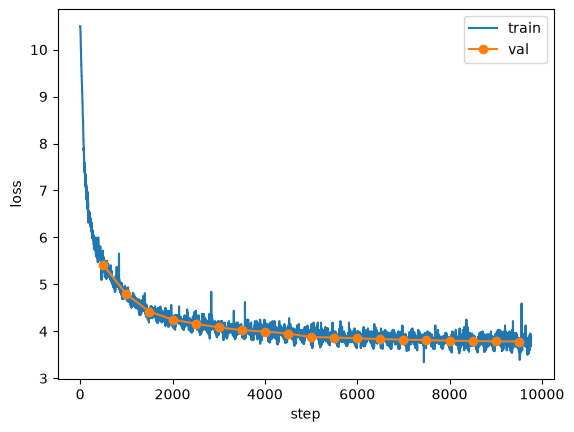

In [8]:
import json
import matplotlib.pyplot as plt

rows = [json.loads(l) for l in open('/kaggle/working/train_log.jsonl')]
steps = [r['step'] for r in rows]
losses = [r['loss'] for r in rows]
val = [(r['step'], r['val_loss']) for r in rows if r.get('val_loss') is not None]

plt.plot(steps, losses, label='train')
if val:
    plt.plot(*zip(*val), 'o-', label='val')
plt.xlabel('step'); plt.ylabel('loss'); plt.legend(); plt.show()

In [9]:
# Load final checkpoint and generate 3 samples (smoke; real sampling in Phase 6).
import os, sys
REPO = '/kaggle/working/llm_forge'
sys.path.insert(0, REPO)  # notebook kernel is python3.12; repo lives outside its site-packages
os.chdir(REPO)           # so relative paths (configs/...) resolve
import jax, jax.numpy as jnp
from pathlib import Path
from model.config import load_model_config
from model.lm import LM
from training.state import create_train_state, restore
from training.config import load_training_config

print(f'CWD: {os.getcwd()}')
print(f'configs/training/ exists: {Path("configs/training").exists()}')
if Path('configs/training').exists():
    print(f'  contents: {sorted(p.name for p in Path("configs/training").iterdir())}')

cfg = load_model_config('model_25m')
train_cfg = load_training_config('configs/training/model_25m.yaml')
model = LM(config=cfg)
state = create_train_state(jax.random.PRNGKey(0), model, train_cfg, cfg)  # placeholder params
# state = restore('/kaggle/working/ckpt/step_000009766_final', state)  # uncomment after full run

prompt = jnp.array([[3, 4, 5, 6]], dtype=jnp.int32)  # <|bos|> + 3 random tokens
loss, logits = model.apply(state.params, prompt, prompt, return_logits=True)
print('logits shape:', logits.shape, '(full sampling lives in Phase 6)')
next_token = int(jnp.argmax(logits[0, -1]))
print(f'argmax of last-position logits -> token id {next_token} (vocab 32768; untrained -> mostly noise)')

/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:88: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


CWD: /kaggle/working/llm_forge
configs/training/ exists: True
  contents: ['model_25m.yaml', 'smoke_test.yaml']


E0000 00:00:1783071995.543187      14 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: ===
learning/45eac/tfrc/runtime/common_lib.cc:238


logits shape: (1, 4, 32768) (full sampling lives in Phase 6)
argmax of last-position logits -> token id 3465 (vocab 32768; untrained -> mostly noise)


In [11]:
# Push the final HF export to adesh01/llm_forge-25m.
# Requires `huggingface-cli login` (or HF_TOKEN env) with a write token.
# training/train.py already wrote the export to
# /kaggle/working/ckpt/step_<N>_final/hf/ — this cell just uploads it.
import os
from training.export_hf import push_to_hub
from pathlib import Path

final_dir = sorted(Path('/kaggle/working/ckpt').glob('step_*_final'))[-1]
hf_dir = final_dir / 'hf'
assert hf_dir.exists(), f'no HF export at {hf_dir}; did cell 13 finish?'

print(f'pushing {hf_dir} -> adesh01/llm_forge-25m (public)')
url = push_to_hub(hf_dir, 'adesh01/llm_forge-25m', private=False, commit_message='Initial 1B-token pretrain')
print('uploaded:', url)

# Optional: if the README on the hub is missing the YAML frontmatter
# (HF shows a "empty or missing yaml metadata" warning), re-push
# just the README from the static template — no 111MB re-upload:
#
# from training.export_hf import push_readme_to_hub
# push_readme_to_hub('experiments/hf_readme_template.md', 'adesh01/llm_forge-25m',
#                     commit_message='Add YAML frontmatter to README')


pushing /kaggle/working/ckpt/step_0000009766_final/hf -> adesh01/llm_forge-25m (public)


HfHubHTTPError: 401 Client Error: Unauthorized for url: https://huggingface.co/api/repos/create (Request ID: Root=1-6a4785b2-0bcc4d044c7c67c7696fac44;93412938-73c6-4bd6-9e65-55a5fd0c157d)

Invalid username or password.